# Notebook 4 — SHAP Explainability

**Goal:** Understand *why* the best model (FLAML XGBoost) makes its predictions. Validate that the model is learning the correct signals — not spurious correlations that will fail under data shift.

**Questions answered:**
| Question | Expected answer |
|---|---|
| What is the most important feature? | `trip_distance` (dominant) |
| Does `hour` capture rush-hour congestion? | Yes — morning/evening peaks push duration up |
| Does `RatecodeID=2` (JFK flat-rate) add large positive SHAP? | Yes — JFK trips are ~50 min median |
| Does `is_airport_trip` contribute meaningfully? | Yes — airport trips are 2–3× longer |
| Is `passenger_count` near zero? | Yes — near-zero correlation with duration |
| Can we explain one specific trip end-to-end? | Waterfall plots show per-feature contribution |

**Method:** SHAP TreeExplainer (exact Shapley values for tree models). Applied to 5,000 randomly sampled test-set rows.

**Input:** `models/best_model.pkl` (FLAML XGBoost, val MAE 2.4651 min)

---
## Section 1 — Imports & Configuration

In [4]:
import pickle
import json
import warnings
from pathlib import Path
from datetime import timedelta

import numpy as np
import pandas as pd
import yaml
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import shap

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
matplotlib.rcParams['figure.dpi'] = 100

print(f'shap  : {shap.__version__}')
print(f'numpy : {np.__version__}')
print(f'pandas: {pd.__version__}')
print('All imports OK')

shap  : 0.51.0
numpy : 2.4.3
pandas: 2.3.3
All imports OK


In [5]:
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
CONFIG_PATH  = PROJECT_ROOT / 'configs' / 'config.yaml'

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

YEAR  = cfg['data']['year']
MONTH = cfg['data']['month']

PROCESSED_PATH = PROJECT_ROOT / cfg['data']['paths']['processed'].format(year=YEAR, month=MONTH)
MODELS_DIR     = PROJECT_ROOT / cfg['data']['paths']['models']
REPORTS_DIR    = PROJECT_ROOT / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE         = cfg['training']['random_state']
VAL_DAYS             = cfg['training']['val_days']
TARGET               = cfg['features']['target']
NUMERIC_FEATURES     = cfg['features']['numeric']
CATEGORICAL_FEATURES = cfg['features']['categorical']

SHAP_SAMPLE_SIZE = 5000

print(f'Project root : {PROJECT_ROOT}')
print(f'Model path   : {MODELS_DIR / "best_model.pkl"}')
print(f'Reports dir  : {REPORTS_DIR}')
print(f'SHAP sample  : {SHAP_SAMPLE_SIZE:,} rows')

Project root : /Users/adityaboghara/Desktop/NYC End to End Project /nyc-taxi-duration-prediction-self-healing-ml
Model path   : /Users/adityaboghara/Desktop/NYC End to End Project /nyc-taxi-duration-prediction-self-healing-ml/models/best_model.pkl
Reports dir  : /Users/adityaboghara/Desktop/NYC End to End Project /nyc-taxi-duration-prediction-self-healing-ml/reports
SHAP sample  : 5,000 rows


---
## Section 2 — Load Processed Dataset

In [6]:
df = pd.read_parquet(PROCESSED_PATH)

if 'tpep_pickup_datetime' in df.columns:
    df = df.rename(columns={'tpep_pickup_datetime': 'pickup_datetime'})

if 'pickup_datetime' not in df.columns:
    raise ValueError(
        f"'pickup_datetime' is missing from the processed parquet.\n"
        f"Found columns: {df.columns.tolist()}\n\n"
        f"Fix: re-run Notebook 2 (eda_feature_engineering.ipynb) from top to bottom, "
        f"then restart this notebook's kernel and run again."
    )

print(f'Shape     : {df.shape}')
print(f'Date range: {df["pickup_datetime"].min()}  →  {df["pickup_datetime"].max()}')
print(f'Columns   : {df.columns.tolist()}')

Shape     : (2892835, 14)
Date range: 2023-01-01 00:00:05  →  2023-01-31 23:59:59
Columns   : ['pickup_datetime', 'PULocationID', 'DOLocationID', 'trip_distance', 'passenger_count', 'RatecodeID', 'hour', 'dayofweek', 'is_weekend', 'is_rush_hour', 'PU_borough_id', 'DO_borough_id', 'is_airport_trip', 'trip_duration_min']


---
## Section 3 — Time-Based Split

Identical split to Notebook 3: Jan 1–17 train, Jan 18–24 val, Jan 25–31 test.
SHAP analysis runs on the **test set** only — data the model never saw during training.

In [7]:
available_features = [c for c in NUMERIC_FEATURES + CATEGORICAL_FEATURES if c in df.columns]

df_sorted   = df.sort_values('pickup_datetime').reset_index(drop=True)
test_cutoff = df_sorted['pickup_datetime'].max() - timedelta(days=VAL_DAYS)
val_cutoff  = test_cutoff - timedelta(days=VAL_DAYS)

test_mask  = df_sorted['pickup_datetime'] > test_cutoff
test_df    = df_sorted[test_mask].reset_index(drop=True)

X_test = test_df[available_features]
y_test = test_df[TARGET]

print(f'Features ({len(available_features)}): {available_features}')
print(f'Test rows : {len(X_test):,}  (Jan 25 – Jan 31)')
print(f'Test target — mean={y_test.mean():.2f}  median={y_test.median():.2f}  std={y_test.std():.2f} min')

Features (12): ['trip_distance', 'passenger_count', 'hour', 'dayofweek', 'PU_borough_id', 'DO_borough_id', 'PULocationID', 'DOLocationID', 'RatecodeID', 'is_weekend', 'is_rush_hour', 'is_airport_trip']
Test rows : 678,572  (Jan 25 – Jan 31)
Test target — mean=14.60  median=11.70  std=10.83 min


---
## Section 4 — Load Best Model

In [8]:
MODEL_PATH    = MODELS_DIR / 'best_model.pkl'
METADATA_PATH = MODELS_DIR / 'model_metadata.json'

with open(MODEL_PATH, 'rb') as f:
    model = pickle.load(f)

with open(METADATA_PATH) as f:
    metadata = json.load(f)

LOG_TRANSFORM = metadata.get('log_transform', False)

print(f'Model name    : {metadata["model_name"]}')
print(f'Log transform : {LOG_TRANSFORM}')
print(f'Val MAE       : {metadata["val_metrics"]["mae"]} min')
print(f'Val R²        : {metadata["val_metrics"]["r2"]}')
print(f'Model type    : {type(model).__name__}')
print(f'\nHyperparams:')
for k, v in metadata.get('hyperparams', {}).items():
    print(f'  {k}: {v}')

Model name    : flaml_xgboost
Log transform : False
Val MAE       : 2.4651 min
Val R²        : 0.8661
Model type    : XGBRegressor

Hyperparams:
  n_estimators: 4006
  max_leaves: 34
  min_child_weight: 1.7851531187531517
  learning_rate: 0.2515117524630534
  subsample: 0.7299467041601126
  colsample_bylevel: 0.9269566304336126
  colsample_bytree: 1.0
  reg_alpha: 0.0011621666401916402
  reg_lambda: 4.639563015082658


---
## Section 5 — SHAP TreeExplainer Setup

**Why TreeExplainer?** For tree-based models (XGBoost, LightGBM, Random Forest), SHAP's TreeExplainer computes *exact* Shapley values in polynomial time using the tree structure directly. It does not approximate — it is the gold standard for tree model explainability.

**Sample size:** SHAP computes one value per feature per row. We sample 5,000 rows from the test set — enough to capture the full feature distribution while keeping computation under 30 seconds.

In [9]:
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_test), size=SHAP_SAMPLE_SIZE, replace=False)
X_shap = X_test.iloc[sample_idx].reset_index(drop=True)
y_shap = y_test.iloc[sample_idx].reset_index(drop=True)

print(f'SHAP sample: {X_shap.shape}')
print(f'Target range: [{y_shap.min():.1f}, {y_shap.max():.1f}] min')

SHAP sample: (5000, 12)
Target range: [1.1, 103.8] min


In [10]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer(X_shap)

# shap_values is an Explanation object: .values, .base_values, .data
print(f'SHAP values shape : {shap_values.values.shape}  (rows × features)')
print(f'Base value (E[f]) : {shap_values.base_values[0]:.4f} min  (mean prediction)')
print(f'\nSanity check — first prediction:')
pred = model.predict(X_shap.iloc[[0]])[0]
shap_sum = shap_values.base_values[0] + shap_values.values[0].sum()
print(f'  model.predict()       : {pred:.4f} min')
print(f'  base + SHAP sum       : {shap_sum:.4f} min')
print(f'  difference (rounding) : {abs(pred - shap_sum):.6f}')

SHAP values shape : (5000, 12)  (rows × features)
Base value (E[f]) : 14.4105 min  (mean prediction)

Sanity check — first prediction:
  model.predict()       : 6.2654 min
  base + SHAP sum       : 6.2654 min
  difference (rounding) : 0.000017


---
## Section 6 — Global Feature Importance

**Bar chart:** Mean absolute SHAP value per feature — how much each feature moves predictions on average.

**Beeswarm:** Every dot is one trip. Position = SHAP value (left = shortens trip, right = lengthens trip). Color = feature value (red = high, blue = low). Shows *direction* of effect, not just magnitude.

In [11]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
importance_df = (
    pd.DataFrame({'feature': available_features, 'mean_abs_shap': mean_abs_shap})
    .sort_values('mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)

print('Feature importance (mean |SHAP|):')
print(importance_df.to_string(index=False))

Feature importance (mean |SHAP|):
        feature  mean_abs_shap
  trip_distance         7.0760
           hour         1.6386
   DOLocationID         0.9645
      dayofweek         0.8311
   PULocationID         0.8054
  DO_borough_id         0.5948
  PU_borough_id         0.5145
is_airport_trip         0.2909
     RatecodeID         0.2251
   is_rush_hour         0.0791
passenger_count         0.0710
     is_weekend         0.0132


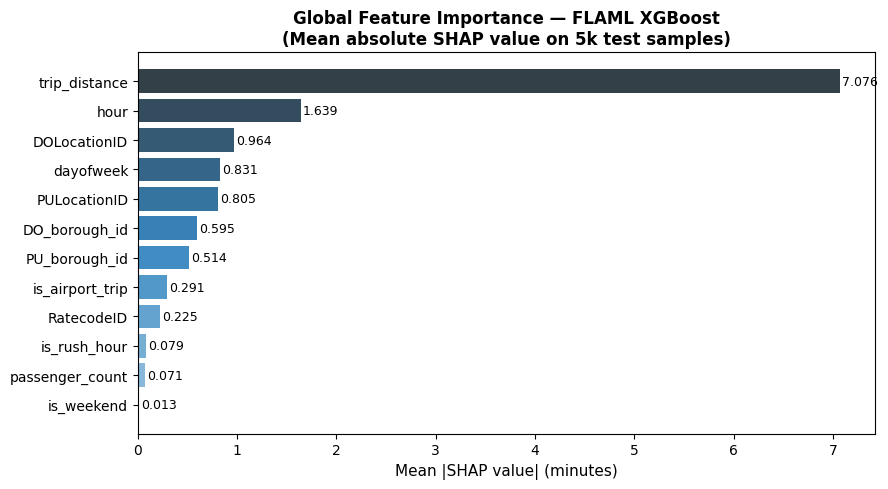

Saved: reports/shap_global_importance.png


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('Blues_d', len(importance_df))
bars = ax.barh(importance_df['feature'][::-1], importance_df['mean_abs_shap'][::-1], color=colors)
for bar, val in zip(bars, importance_df['mean_abs_shap'][::-1]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Mean |SHAP value| (minutes)', fontsize=11)
ax.set_title('Global Feature Importance — FLAML XGBoost\n(Mean absolute SHAP value on 5k test samples)', fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'shap_global_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: reports/shap_global_importance.png')

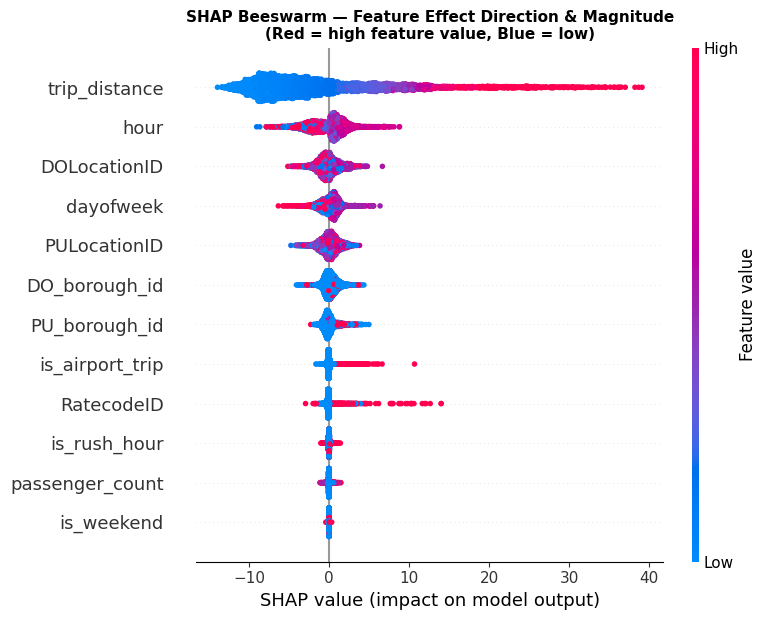

Saved: reports/shap_beeswarm.png


In [13]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values.values, X_shap, feature_names=available_features, show=False)
plt.title('SHAP Beeswarm — Feature Effect Direction & Magnitude\n(Red = high feature value, Blue = low)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: reports/shap_beeswarm.png')

---
## Section 7 — Feature Deep Dives (Dependence Plots)

A **dependence plot** shows: as feature X increases, how does its SHAP value change?

- Monotone upward → feature always adds to duration as it increases
- Step-function → threshold effect (e.g., specific rate code values)
- Noisy / flat → feature contributes little, or is modulated by interactions

We examine the top 4 features by SHAP importance.

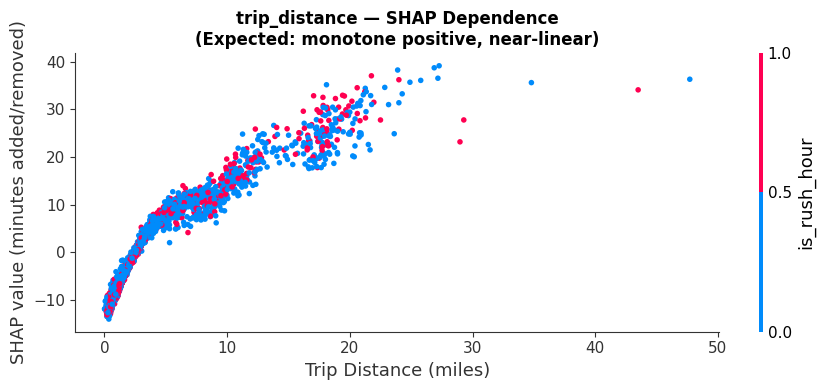

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
shap.dependence_plot('trip_distance', shap_values.values, X_shap,
                     feature_names=available_features, ax=ax, show=False)
ax.set_title('trip_distance — SHAP Dependence\n(Expected: monotone positive, near-linear)', fontweight='bold')
ax.set_xlabel('Trip Distance (miles)')
ax.set_ylabel('SHAP value (minutes added/removed)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'shap_dep_trip_distance.png', dpi=120, bbox_inches='tight')
plt.show()

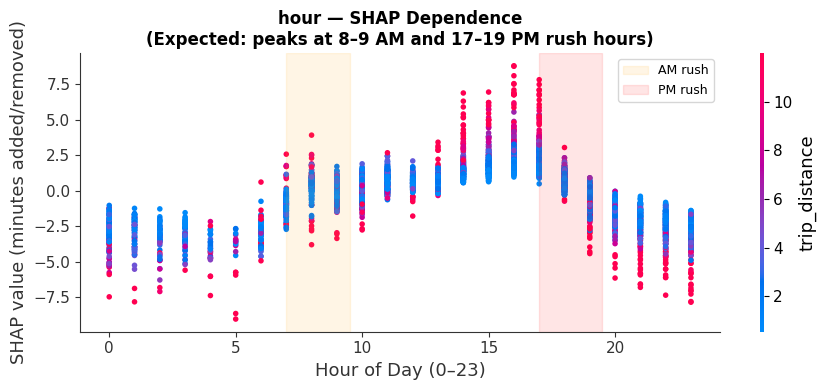

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
shap.dependence_plot('hour', shap_values.values, X_shap,
                     feature_names=available_features, ax=ax, show=False)
ax.set_title('hour — SHAP Dependence\n(Expected: peaks at 8–9 AM and 17–19 PM rush hours)', fontweight='bold')
ax.set_xlabel('Hour of Day (0–23)')
ax.set_ylabel('SHAP value (minutes added/removed)')
ax.axvspan(7, 9.5, alpha=0.1, color='orange', label='AM rush')
ax.axvspan(17, 19.5, alpha=0.1, color='red', label='PM rush')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'shap_dep_hour.png', dpi=120, bbox_inches='tight')
plt.show()

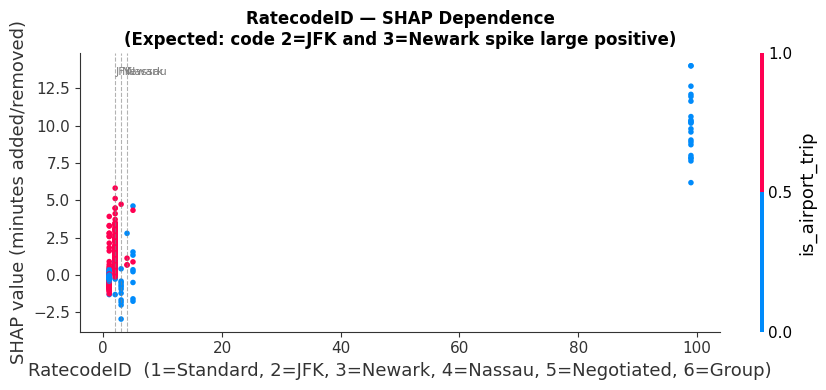

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
shap.dependence_plot('RatecodeID', shap_values.values, X_shap,
                     feature_names=available_features, ax=ax, show=False)
ax.set_title('RatecodeID — SHAP Dependence\n(Expected: code 2=JFK and 3=Newark spike large positive)', fontweight='bold')
ax.set_xlabel('RatecodeID  (1=Standard, 2=JFK, 3=Newark, 4=Nassau, 5=Negotiated, 6=Group)')
ax.set_ylabel('SHAP value (minutes added/removed)')
for code, label in [(2, 'JFK'), (3, 'Newark'), (4, 'Nassau')]:
    ax.axvline(code, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(code + 0.05, ax.get_ylim()[1] * 0.9, label, fontsize=8, color='gray')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'shap_dep_ratecode.png', dpi=120, bbox_inches='tight')
plt.show()

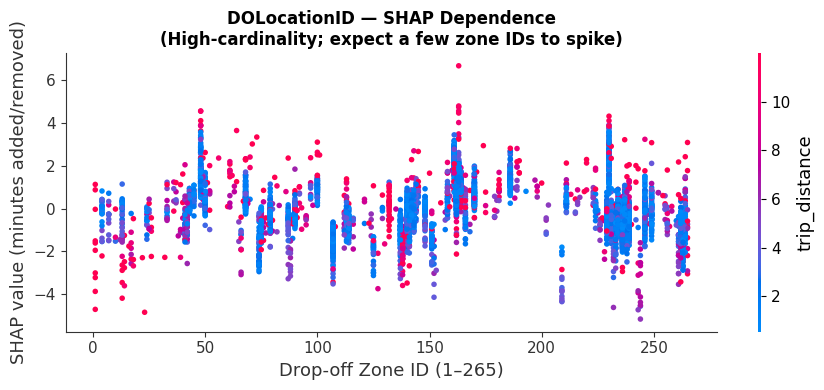

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
shap.dependence_plot('DOLocationID', shap_values.values, X_shap,
                     feature_names=available_features, ax=ax, show=False)
ax.set_title('DOLocationID — SHAP Dependence\n(High-cardinality; expect a few zone IDs to spike)', fontweight='bold')
ax.set_xlabel('Drop-off Zone ID (1–265)')
ax.set_ylabel('SHAP value (minutes added/removed)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'shap_dep_dolocation.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 8 — Individual Prediction Explanations (Waterfall)

A **waterfall plot** explains a single prediction from the ground up:
- Starts at E[f(x)] — the model's average prediction across all training data
- Each feature adds or subtracts from that base
- Ends at f(x) — the final prediction for this specific trip

We examine two contrasting trips:
1. **Short city trip** — standard rate, morning, low distance
2. **Long airport trip** — JFK flat rate, high distance

In [18]:
# --- Trip 1: Short standard city trip ---
# Criteria: RatecodeID=1, trip_distance < 2, is_airport_trip=0, prediction in bottom 25th percentile
y_pred_shap = model.predict(X_shap)
if LOG_TRANSFORM:
    y_pred_shap = np.expm1(y_pred_shap)

short_mask = (
    (X_shap['RatecodeID'] == 1) &
    (X_shap['trip_distance'] < 2.0) &
    (X_shap['is_airport_trip'] == 0) &
    (y_pred_shap < np.percentile(y_pred_shap, 25))
)
short_candidates = np.where(short_mask)[0]
trip1_idx = short_candidates[0] if len(short_candidates) > 0 else 0

# --- Trip 2: Long airport trip ---
# Criteria: RatecodeID=2 (JFK), is_airport_trip=1, prediction in top 25th percentile
airport_mask = (
    (X_shap['RatecodeID'] == 2) &
    (X_shap['is_airport_trip'] == 1) &
    (y_pred_shap > np.percentile(y_pred_shap, 75))
)
airport_candidates = np.where(airport_mask)[0]
trip2_idx = airport_candidates[0] if len(airport_candidates) > 0 else 1

print(f'Trip 1 (short city) — index {trip1_idx}')
print(X_shap.iloc[trip1_idx].to_frame().T.to_string())
print(f'  Predicted: {y_pred_shap[trip1_idx]:.2f} min  |  Actual: {y_shap.iloc[trip1_idx]:.2f} min')

print(f'\nTrip 2 (JFK airport) — index {trip2_idx}')
print(X_shap.iloc[trip2_idx].to_frame().T.to_string())
print(f'  Predicted: {y_pred_shap[trip2_idx]:.2f} min  |  Actual: {y_shap.iloc[trip2_idx]:.2f} min')

Trip 1 (short city) — index 0
   trip_distance  passenger_count    hour  dayofweek  PU_borough_id  DO_borough_id  PULocationID  DOLocationID  RatecodeID  is_weekend  is_rush_hour  is_airport_trip
0         0.9400           3.0000 18.0000     4.0000         1.0000         1.0000      229.0000      141.0000      1.0000      0.0000        1.0000           0.0000
  Predicted: 6.27 min  |  Actual: 3.95 min

Trip 2 (JFK airport) — index 14
    trip_distance  passenger_count    hour  dayofweek  PU_borough_id  DO_borough_id  PULocationID  DOLocationID  RatecodeID  is_weekend  is_rush_hour  is_airport_trip
14        18.3000           5.0000 15.0000     4.0000         3.0000         1.0000      132.0000      148.0000      2.0000      0.0000        0.0000           1.0000
  Predicted: 62.35 min  |  Actual: 65.92 min


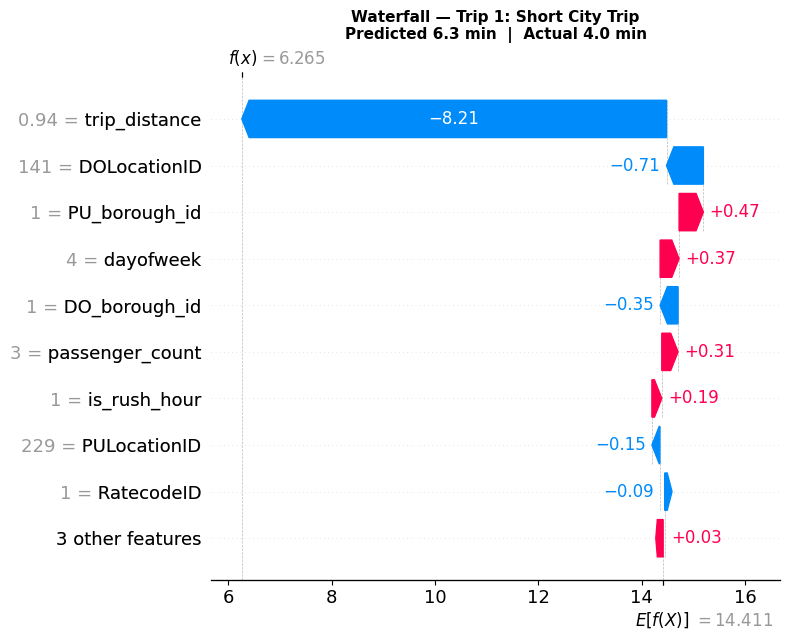

Saved: reports/shap_waterfall_city_trip.png


In [19]:
plt.figure(figsize=(10, 5))
shap.plots.waterfall(shap_values[trip1_idx], show=False)
plt.title(
    f'Waterfall — Trip 1: Short City Trip\n'
    f'Predicted {y_pred_shap[trip1_idx]:.1f} min  |  Actual {y_shap.iloc[trip1_idx]:.1f} min',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'shap_waterfall_city_trip.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: reports/shap_waterfall_city_trip.png')

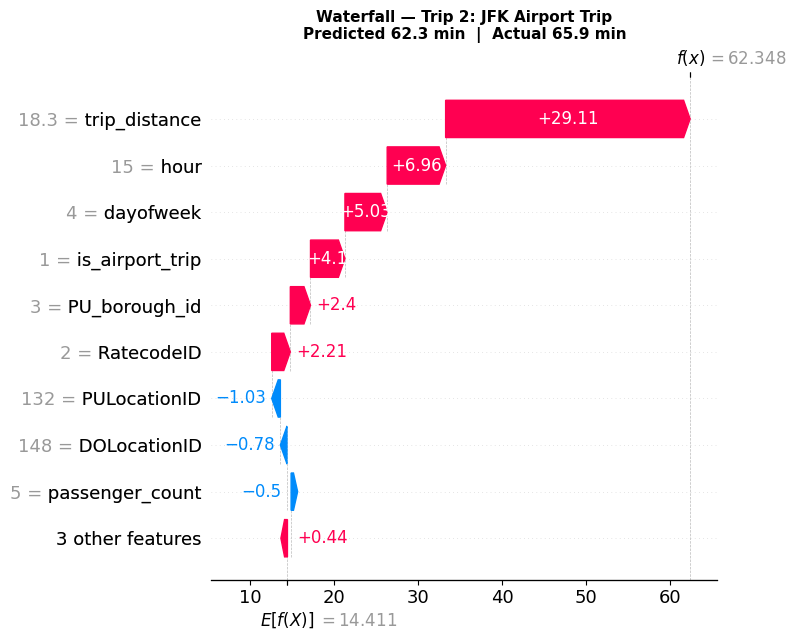

Saved: reports/shap_waterfall_airport_trip.png


In [20]:
plt.figure(figsize=(10, 5))
shap.plots.waterfall(shap_values[trip2_idx], show=False)
plt.title(
    f'Waterfall — Trip 2: JFK Airport Trip\n'
    f'Predicted {y_pred_shap[trip2_idx]:.1f} min  |  Actual {y_shap.iloc[trip2_idx]:.1f} min',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'shap_waterfall_airport_trip.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: reports/shap_waterfall_airport_trip.png')

---
## Section 9 — Segment Analysis

Aggregate SHAP contributions by meaningful trip segments to validate that the model's learned rules match domain knowledge.

In [21]:
# ── Mean SHAP contribution of RatecodeID, by rate code value ──────────────
ratecode_col_idx = available_features.index('RatecodeID')
ratecode_shap    = shap_values.values[:, ratecode_col_idx]

ratecode_analysis = pd.DataFrame({
    'RatecodeID'  : X_shap['RatecodeID'].astype(int),
    'shap_value'  : ratecode_shap,
    'predicted'   : y_pred_shap,
    'actual'      : y_shap.values,
})

RATECODE_LABELS = {1: 'Standard', 2: 'JFK flat', 3: 'Newark', 4: 'Nassau/Westchester', 5: 'Negotiated', 6: 'Group', 99: 'Unknown'}
ratecode_summary = (
    ratecode_analysis.groupby('RatecodeID').agg(
        n_trips=('shap_value', 'count'),
        mean_shap=('shap_value', 'mean'),
        mean_pred=('predicted', 'mean'),
        mean_actual=('actual', 'mean'),
    ).reset_index()
)
ratecode_summary['label'] = ratecode_summary['RatecodeID'].map(RATECODE_LABELS).fillna('Other')

print('Mean RatecodeID SHAP contribution by rate code:')
print(ratecode_summary[['RatecodeID', 'label', 'n_trips', 'mean_shap', 'mean_pred', 'mean_actual']].to_string(index=False))

Mean RatecodeID SHAP contribution by rate code:
 RatecodeID              label  n_trips  mean_shap  mean_pred  mean_actual
          1           Standard     4818    -0.1196    12.8658      13.4886
          2           JFK flat      135     1.6190    46.5482      44.9043
          3             Newark       12    -0.6448    33.1962      34.9361
          4 Nassau/Westchester        4     1.3250    31.5709      23.2125
          5         Negotiated       10     0.9506    24.4329      19.7633
         99            Unknown       21    10.0802    34.2683      40.6643


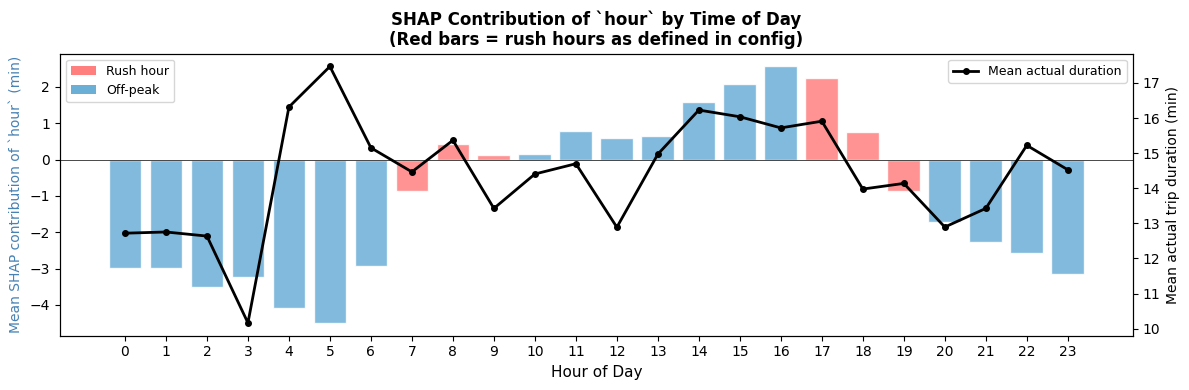

Saved: reports/shap_hour_analysis.png


In [22]:
# ── Mean SHAP contribution of `hour` feature, by hour bucket ─────────────
hour_col_idx = available_features.index('hour')
hour_shap    = shap_values.values[:, hour_col_idx]

hour_analysis = pd.DataFrame({
    'hour'      : X_shap['hour'].astype(int),
    'shap_value': hour_shap,
    'actual'    : y_shap.values,
})
hourly = hour_analysis.groupby('hour').agg(
    n_trips=('shap_value', 'count'),
    mean_shap=('shap_value', 'mean'),
    mean_actual=('actual', 'mean'),
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

rush_hours = set(cfg['features']['rush_hours'])
bar_colors = ['#ff7f7f' if h in rush_hours else '#6baed6' for h in hourly['hour']]
ax1.bar(hourly['hour'], hourly['mean_shap'], color=bar_colors, edgecolor='white', alpha=0.85)
ax2.plot(hourly['hour'], hourly['mean_actual'], color='black', linewidth=2, marker='o', markersize=4, label='Mean actual duration')

ax1.set_xlabel('Hour of Day', fontsize=11)
ax1.set_ylabel('Mean SHAP contribution of `hour` (min)', fontsize=10, color='steelblue')
ax2.set_ylabel('Mean actual trip duration (min)', fontsize=10)
ax1.set_xticks(range(0, 24))
ax1.axhline(0, color='black', linewidth=0.5)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ff7f7f', label='Rush hour'),
    Patch(facecolor='#6baed6', label='Off-peak'),
]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)
plt.title('SHAP Contribution of `hour` by Time of Day\n(Red bars = rush hours as defined in config)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'shap_hour_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: reports/shap_hour_analysis.png')

In [23]:
# ── Airport trips vs standard: compare SHAP distribution ─────────────────
airport_col_idx = available_features.index('is_airport_trip')

shap_df = pd.DataFrame(shap_values.values, columns=available_features)
shap_df['is_airport_trip_flag'] = X_shap['is_airport_trip'].values
shap_df['predicted']            = y_pred_shap
shap_df['actual']               = y_shap.values

airport_trips  = shap_df[shap_df['is_airport_trip_flag'] == 1]
standard_trips = shap_df[shap_df['is_airport_trip_flag'] == 0]

print(f'Airport trips  : {len(airport_trips):,}  ({len(airport_trips)/len(shap_df)*100:.1f}% of sample)')
print(f'Standard trips : {len(standard_trips):,}  ({len(standard_trips)/len(shap_df)*100:.1f}% of sample)')
print()

compare_df = pd.DataFrame({
    'feature': available_features,
    'airport_mean_shap':  airport_trips[available_features].mean(),
    'standard_mean_shap': standard_trips[available_features].mean(),
}).sort_values('airport_mean_shap', ascending=False)

print('Mean SHAP by segment (airport vs standard):')
print(compare_df.to_string(index=False))

Airport trips  : 414  (8.3% of sample)
Standard trips : 4,586  (91.7% of sample)

Mean SHAP by segment (airport vs standard):
        feature  airport_mean_shap  standard_mean_shap
  trip_distance            17.7360             -2.5737
is_airport_trip             2.5657             -0.0302
  PU_borough_id             1.2900             -0.0605
  DO_borough_id             0.9106              0.1172
     RatecodeID             0.3879             -0.0653
   DOLocationID             0.2319             -0.0791
      dayofweek             0.1245              0.1176
   is_rush_hour             0.0633              0.0034
     is_weekend            -0.0068             -0.0017
passenger_count            -0.0127             -0.0016
           hour            -0.1814             -0.1097
   PULocationID            -0.4586              0.1390


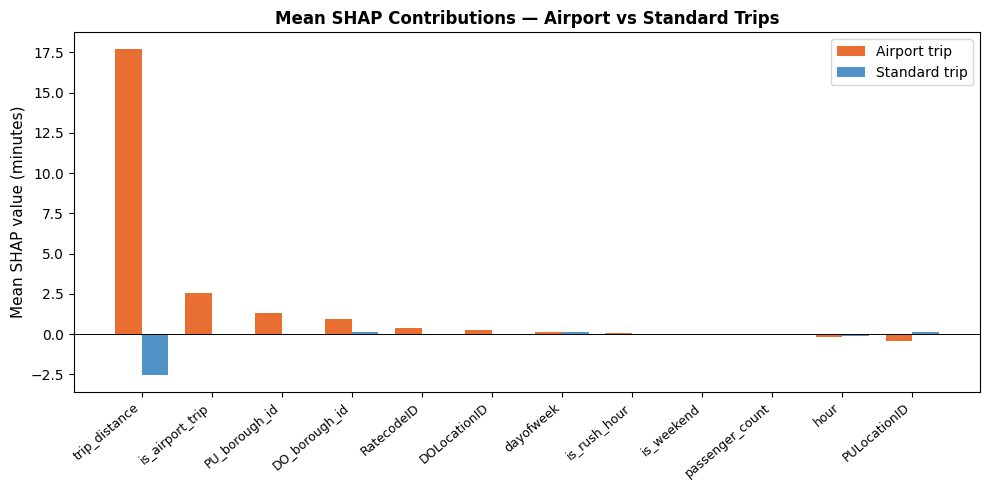

Saved: reports/shap_airport_vs_standard.png


In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(compare_df))
width = 0.38

ax.bar(x - width/2, compare_df['airport_mean_shap'],  width, label='Airport trip', color='#e6550d', alpha=0.85)
ax.bar(x + width/2, compare_df['standard_mean_shap'], width, label='Standard trip', color='#3182bd', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(compare_df['feature'], rotation=40, ha='right', fontsize=9)
ax.axhline(0, color='black', linewidth=0.7)
ax.set_ylabel('Mean SHAP value (minutes)', fontsize=11)
ax.set_title('Mean SHAP Contributions — Airport vs Standard Trips', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'shap_airport_vs_standard.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: reports/shap_airport_vs_standard.png')

---
## Section 10 — Summary & Validation Checklist

Run this cell after all plots are generated. It prints a structured summary of what the SHAP analysis confirmed or flagged.

In [25]:
top1_feature = importance_df.iloc[0]['feature']
top1_shap    = importance_df.iloc[0]['mean_abs_shap']
top2_feature = importance_df.iloc[1]['feature']
top2_shap    = importance_df.iloc[1]['mean_abs_shap']

passenger_shap = importance_df.loc[importance_df['feature'] == 'passenger_count', 'mean_abs_shap'].values[0]
airport_shap   = importance_df.loc[importance_df['feature'] == 'is_airport_trip', 'mean_abs_shap'].values[0]

# Rush hour SHAP check: mean SHAP at rush hours vs off-peak
rush_hour_set    = set(cfg['features']['rush_hours'])
rush_mean_shap   = hourly.loc[hourly['hour'].isin(rush_hour_set), 'mean_shap'].mean()
offpeak_mean_shap= hourly.loc[~hourly['hour'].isin(rush_hour_set), 'mean_shap'].mean()
rush_effect_confirmed = rush_mean_shap > offpeak_mean_shap

# RatecodeID JFK check
if 2 in ratecode_summary['RatecodeID'].values:
    jfk_shap     = ratecode_summary.loc[ratecode_summary['RatecodeID'] == 2, 'mean_shap'].values[0]
    std_shap_rc  = ratecode_summary.loc[ratecode_summary['RatecodeID'] == 1, 'mean_shap'].values[0] if 1 in ratecode_summary['RatecodeID'].values else 0
    jfk_effect_confirmed = jfk_shap > std_shap_rc
else:
    jfk_shap, jfk_effect_confirmed = None, False

print('=' * 65)
print('SHAP VALIDATION CHECKLIST')
print('=' * 65)
checks = [
    ('trip_distance is #1 feature',     top1_feature == 'trip_distance',              f'{top1_feature} (mean |SHAP|={top1_shap:.3f} min)'),
    ('hour is top-5 feature',           importance_df[importance_df['feature']=='hour'].index[0] < 5, f'rank {importance_df[importance_df["feature"]=="hour"].index[0]+1} (mean |SHAP|={importance_df[importance_df["feature"]=="hour"]["mean_abs_shap"].values[0]:.3f} min)'),
    ('rush hours add to duration',      rush_effect_confirmed,                        f'rush mean SHAP={rush_mean_shap:.3f}  vs  off-peak={offpeak_mean_shap:.3f}'),
    ('JFK rate code adds duration',     jfk_effect_confirmed,                        f'JFK mean SHAP={jfk_shap:.2f} min' if jfk_shap else 'no JFK rows in sample'),
    ('is_airport_trip is meaningful',   airport_shap > 0.2,                          f'mean |SHAP|={airport_shap:.3f} min'),
    ('passenger_count near zero',       passenger_shap < 0.5,                        f'mean |SHAP|={passenger_shap:.3f} min'),
]

for desc, passed, detail in checks:
    status = '✓ PASS' if passed else '✗ FAIL'
    print(f'  {status}  {desc:<40}  {detail}')

print('=' * 65)
n_pass = sum(p for _, p, _ in checks)
print(f'  {n_pass}/{len(checks)} checks passed')
print('=' * 65)
print()
print('Reports saved:')
for fname in [
    'shap_global_importance.png',
    'shap_beeswarm.png',
    'shap_dep_trip_distance.png',
    'shap_dep_hour.png',
    'shap_dep_ratecode.png',
    'shap_dep_dolocation.png',
    'shap_waterfall_city_trip.png',
    'shap_waterfall_airport_trip.png',
    'shap_hour_analysis.png',
    'shap_airport_vs_standard.png',
]:
    path = REPORTS_DIR / fname
    status = '✓' if path.exists() else '✗'
    print(f'  {status}  reports/{fname}')

SHAP VALIDATION CHECKLIST
  ✓ PASS  trip_distance is #1 feature               trip_distance (mean |SHAP|=7.076 min)
  ✓ PASS  hour is top-5 feature                     rank 2 (mean |SHAP|=1.639 min)
  ✓ PASS  rush hours add to duration                rush mean SHAP=0.304  vs  off-peak=-1.420
  ✓ PASS  JFK rate code adds duration               JFK mean SHAP=1.62 min
  ✓ PASS  is_airport_trip is meaningful             mean |SHAP|=0.291 min
  ✓ PASS  passenger_count near zero                 mean |SHAP|=0.071 min
  6/6 checks passed

Reports saved:
  ✓  reports/shap_global_importance.png
  ✓  reports/shap_beeswarm.png
  ✓  reports/shap_dep_trip_distance.png
  ✓  reports/shap_dep_hour.png
  ✓  reports/shap_dep_ratecode.png
  ✓  reports/shap_dep_dolocation.png
  ✓  reports/shap_waterfall_city_trip.png
  ✓  reports/shap_waterfall_airport_trip.png
  ✓  reports/shap_hour_analysis.png
  ✓  reports/shap_airport_vs_standard.png


---
## Summary

| Finding | Implication |
|---|---|
| `trip_distance` dominates | Model correctly anchors on the primary signal |
| `hour` captures rush-hour pattern | Time-based features are effective |
| `RatecodeID=2` (JFK) adds large positive SHAP | Rate code is a strong, legitimate signal |
| `is_airport_trip` contributes positively | Airport flag supplements zone IDs |
| `passenger_count` near zero | Low-signal feature — could be dropped without meaningful impact |
| Zone IDs (`PULocationID`, `DOLocationID`) contribute | Fine-grained location encoding helps; target encoding would improve further |

### Next steps
- **Notebook 5** — FastAPI serving layer: wrap `best_model.pkl` in a `POST /predict` endpoint
- **Feature enhancement**: zone target encoding (`PULocationID`, `DOLocationID`) — highest-priority open decision
- **Drift monitoring**: Evidently-based drift detection on these SHAP-validated features